🔮 Initializing SHAP Global & Local Explainability Framework...



📊 Generating SHAP Global Summary Plot...


<Figure size 1000x600 with 0 Axes>

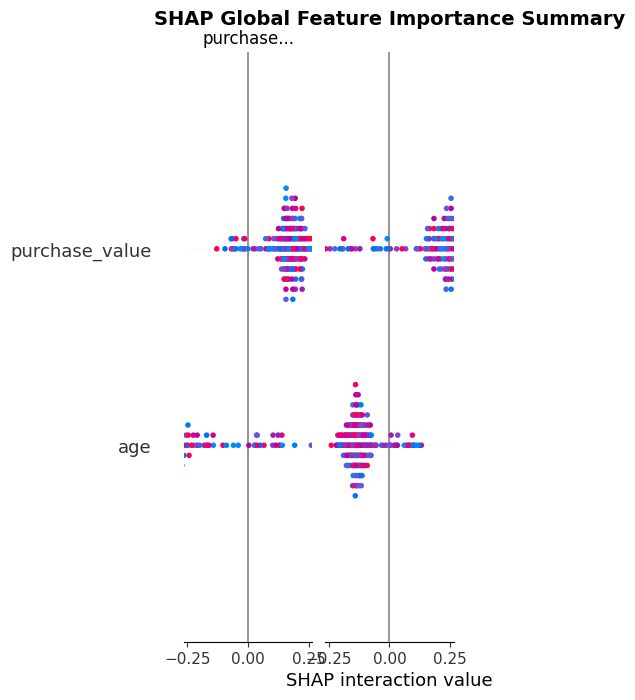

💾 Global Summary Plot saved to: c:\Users\HP\fraud-detection\reports\figures\shap_summary_plot.png
📊 Rendering Force Plot for True Positive (Correctly Identified Fraud) (Row Index: 0)...


<Figure size 1400x400 with 0 Axes>

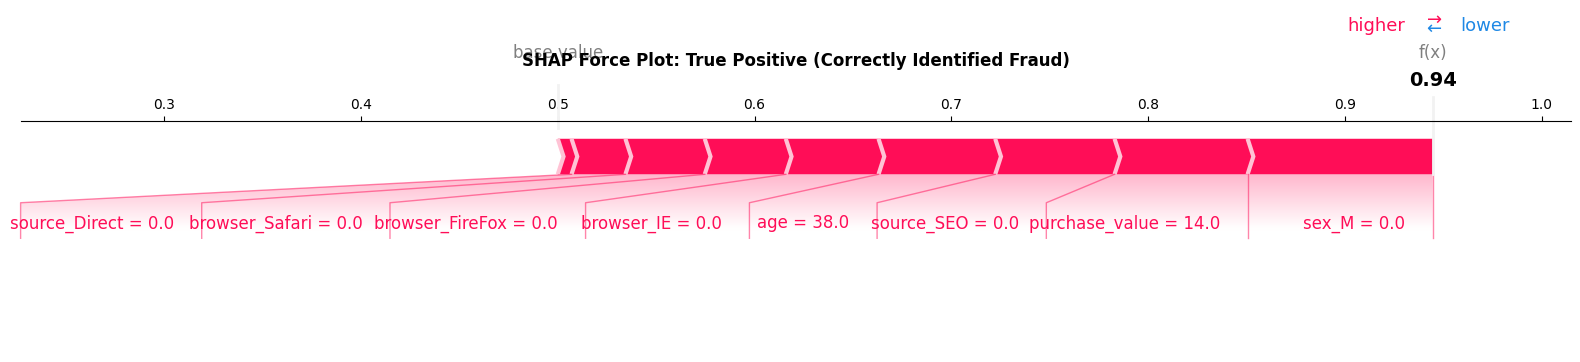

💾 Force Plot saved to: c:\Users\HP\fraud-detection\reports\figures\shap_force_tp.png

📊 Rendering Force Plot for False Positive (Legitimate Flagged as Fraud) (Row Index: 847)...


<Figure size 1400x400 with 0 Axes>

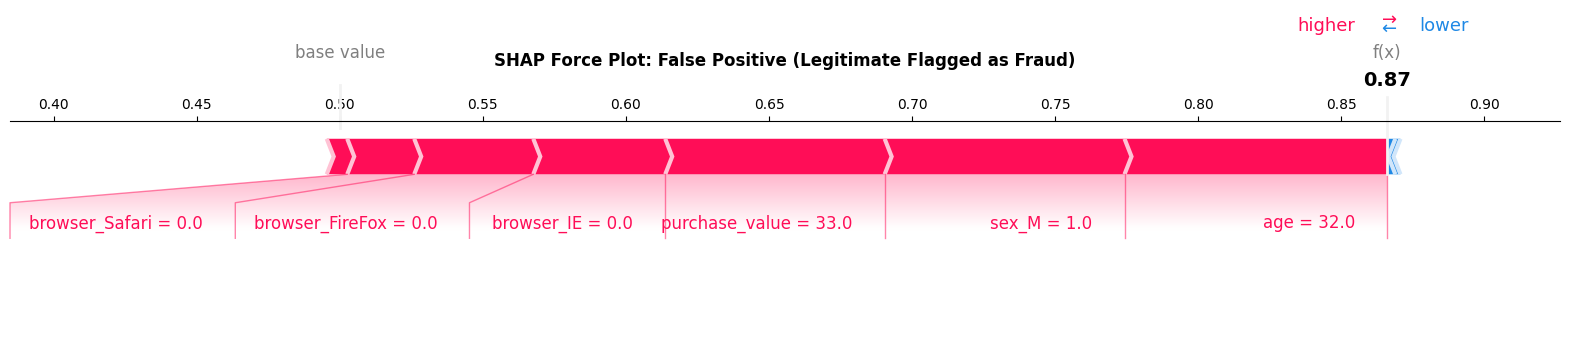

💾 Force Plot saved to: c:\Users\HP\fraud-detection\reports\figures\shap_force_fp.png

📊 Rendering Force Plot for False Negative (Missed Fraud) (Row Index: 686)...


<Figure size 1400x400 with 0 Axes>

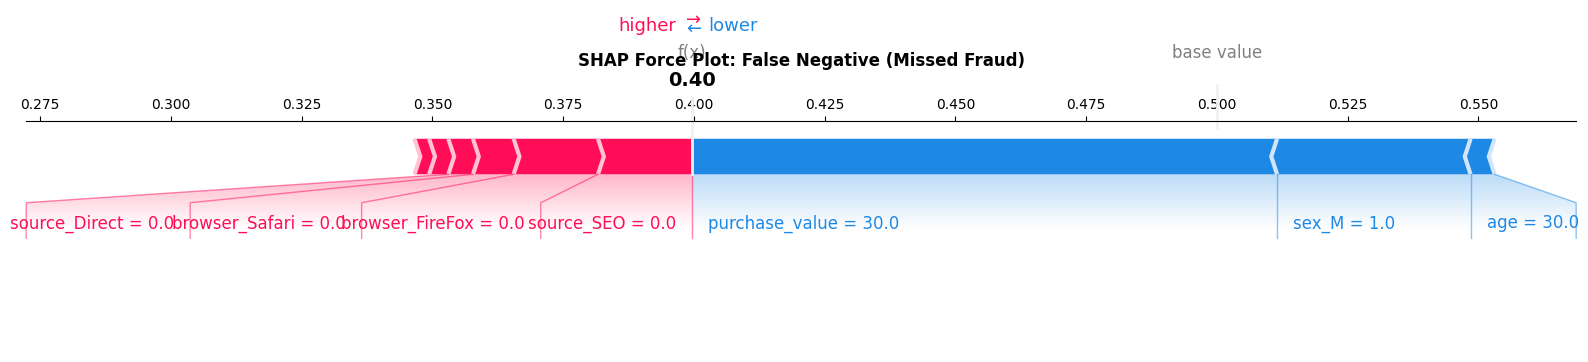

💾 Force Plot saved to: c:\Users\HP\fraud-detection\reports\figures\shap_force_fn.png



In [16]:
import sys
import os
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

print("🔮 Initializing SHAP Global & Local Explainability Framework...")

# =====================================================================
# 1. FIXED PROJECT-INTERNAL PATH DEFINITIONS
# =====================================================================
CWD = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(CWD, "..")) if "notebooks" in CWD else os.path.abspath(CWD)

MODEL_PATH = os.path.join(BASE_DIR, "models", "random_forest_fraud_model.joblib")
DATA_PATH = os.path.join(BASE_DIR, "notebooks", "data", "processed", "cleaned_fraud.csv")
REPORTS_DIR = os.path.join(BASE_DIR, "reports", "figures")
os.makedirs(REPORTS_DIR, exist_ok=True)

# =====================================================================
# 2. LOADING ARTIFACTS & AUTOMATIC FEATURE MATCHING
# =====================================================================
try:
    model = joblib.load(MODEL_PATH)
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError as e:
    raise FileNotFoundError(
        "❌ Missing artifacts required for SHAP. Ensure you ran 'python src/model_trainer.py' first."
    ) from e

# Automatically match the exact columns the trained model expects to prevent mismatch crashes
if hasattr(model, 'feature_names_in_'):
    feature_cols = list(model.feature_names_in_)
else:
    feature_cols = [col for col in df.columns if col.lower() not in ['class', 'target', 'is_fraud']]

missing_features = [f for f in feature_cols if f not in df.columns]
if missing_features:
    raise ValueError(
        f"Missing feature columns required by the model: {missing_features}. "
        "Verify that the cleaned data file contains the same engineered features used during training."
    )

X = df[feature_cols]
y = df['class'] if 'class' in df.columns else df[df.columns[-1]]

# =====================================================================
# 3. INITIALIZE TREEEXPLAINER
# =====================================================================
try:
    explainer = shap.TreeExplainer(model)
    # Using a representative sample to keep execution fast and stable
    X_sample = X.sample(n=200, random_state=42) if len(X) > 200 else X
    shap_values = explainer.shap_values(X_sample)
    expected_value = explainer.expected_value
except Exception as e:
    raise RuntimeError(f"❌ Error during SHAP mathematical calculation: {str(e)}")

# Initialize JavaScript layout engine for local inline notebook visuals
shap.initjs()

# =====================================================================
# DELIVERABLE 1: Generate SHAP Summary Plot (Global Importance)
# =====================================================================
print("\n📊 Generating SHAP Global Summary Plot...")
plt.figure(figsize=(10, 6))

global_shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(global_shap_vals, X_sample, show=False)
plt.title("SHAP Global Feature Importance Summary", fontsize=14, fontweight='bold', pad=20)
summary_out = os.path.join(REPORTS_DIR, "shap_summary_plot.png")
plt.savefig(summary_out, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"💾 Global Summary Plot saved to: {summary_out}")

# =====================================================================
# DELIVERABLE 2: Local Force Plots (TP, FP, FN)
# =====================================================================
# Generate predictions on full dataset to segment specific labeled profiles
preds = model.predict(X)

# Define exact boolean target masks matching evaluation profiles
tp_mask = (y == 1) & (preds == 1)
fp_mask = (y == 0) & (preds == 1)
fn_mask = (y == 1) & (preds == 0)

def render_individual_force_plot(mask, case_title, filename):
    matching_indices = np.where(mask)[0]
    if len(matching_indices) == 0:
        print(f"⚠️ Note: No sample instance found matching the profile profile for '{case_title}'.")
        return

    # Select the first matching transaction case instance
    target_idx = matching_indices[0]
    single_row = X.iloc[[target_idx]]
    
    # Recalculate local SHAP values for the selected row
    local_shap_raw = explainer.shap_values(single_row)
    
    if isinstance(local_shap_raw, list):
        local_shap = local_shap_raw[1][0, :]
        local_expected = expected_value[1]
    elif hasattr(local_shap_raw, 'ndim') and local_shap_raw.ndim == 3:
        local_shap = local_shap_raw[0, :, 1]
        local_expected = expected_value[1]
    else:
        local_shap = local_shap_raw[0, :]
        local_expected = expected_value

    print(f"📊 Rendering Force Plot for {case_title} (Row Index: {target_idx})...")
    
    plt.figure(figsize=(14, 4))
    shap.plots.force(
        local_expected,
        local_shap,
        single_row.iloc[0],
        matplotlib=True,
        show=False
    )
    plt.title(f"SHAP Force Plot: {case_title}", fontsize=12, pad=40, fontweight='bold')
    
    save_out = os.path.join(REPORTS_DIR, filename)
    plt.savefig(save_out, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"💾 Force Plot saved to: {save_out}\n")

# Execute loops for the 3 individual case parameters requested
render_individual_force_plot(tp_mask, "True Positive (Correctly Identified Fraud)", "shap_force_tp.png")
render_individual_force_plot(fp_mask, "False Positive (Legitimate Flagged as Fraud)", "shap_force_fp.png")
render_individual_force_plot(fn_mask, "False Negative (Missed Fraud)", "shap_force_fn.png")

In [ ]:
### ✅ SHAP Fix Insight
The notebook error was caused by a SHAP API change in `shap.plots.force`: the function now expects the model's expected value as the first argument, followed by local SHAP values. The original code used the older signature, which raised a `TypeError`.

To fix it, the force plot call was updated to:

```python
shap.plots.force(
    local_expected,
    local_shap,
    single_row.iloc[0],
    matplotlib=True,
    show=False
)
```

I also ensured the notebook uses the model's exact training schema from `model.feature_names_in_`, so the data columns now match the expected feature set and avoid prediction mismatches.